       Country  Year      Status  Life expectancy  Adult Mortality  \
0  Afghanistan  2015  Developing             65.0            263.0   
1  Afghanistan  2014  Developing             59.9            271.0   
2  Afghanistan  2013  Developing             59.9            268.0   
3  Afghanistan  2012  Developing             59.5            272.0   
4  Afghanistan  2011  Developing             59.2            275.0   

   infant deaths  Alcohol  percentage expenditure  Hepatitis B  Measles  ...  \
0             62     0.01               71.279624         65.0     1154  ...   
1             64     0.01               73.523582         62.0      492  ...   
2             66     0.01               73.219243         64.0      430  ...   
3             69     0.01               78.184215         67.0     2787  ...   
4             71     0.01                7.097109         68.0     3013  ...   

   Polio  Total expenditure  Diphtheria  HIV/AIDS         GDP  Population  \
0    6.0             

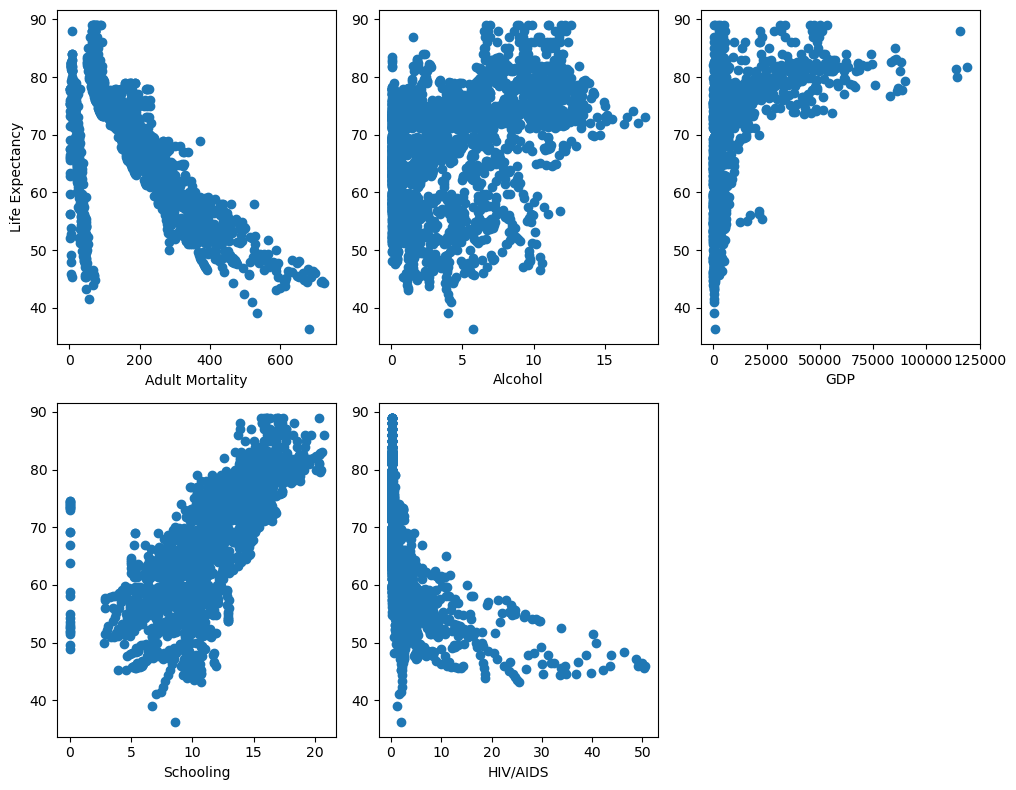

Mean Squared Error: 20.735381733238096
R2 Score: 0.7606589085483269
                 Coefficient
Adult Mortality    -0.025286
Alcohol             0.163961
GDP                 0.000066
Schooling           1.277675
HIV/AIDS           -0.502265


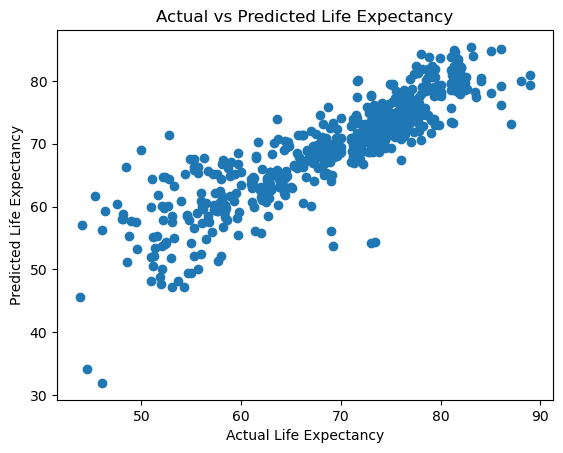

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

url = "https://raw.githubusercontent.com/Vipul97/life-expectancy-prediction/master/Life%20Expectancy%20Data.csv"
df = pd.read_csv(url)

df.columns = df.columns.str.strip()

print(df.head())
print(df.isnull().sum())
print(df.describe())

features = df[['Adult Mortality', 'Alcohol', 'GDP', 'Schooling', 'HIV/AIDS']]
target = df['Life expectancy']

features = features.fillna(features.mean())
target = target.fillna(target.mean())

plt.figure(figsize=(10,8))

plt.subplot(2,3,1)
plt.scatter(df['Adult Mortality'], target)
plt.xlabel("Adult Mortality")
plt.ylabel("Life Expectancy")

plt.subplot(2,3,2)
plt.scatter(df['Alcohol'], target)
plt.xlabel("Alcohol")

plt.subplot(2,3,3)
plt.scatter(df['GDP'], target)
plt.xlabel("GDP")

plt.subplot(2,3,4)
plt.scatter(df['Schooling'], target)
plt.xlabel("Schooling")

plt.subplot(2,3,5)
plt.scatter(df['HIV/AIDS'], target)
plt.xlabel("HIV/AIDS")

plt.tight_layout()
plt.show()

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)

coefficients = pd.DataFrame(model.coef_, features.columns, columns=['Coefficient'])
print(coefficients)

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Actual vs Predicted Life Expectancy")
plt.show()